In [37]:
import numpy as np
from astropy import units as u
from astropy.cosmology import Planck18 as cosmo

In [38]:
from softisoics import isolated_halo
from softisoics.constants import G

In [39]:
import importlib

importlib.reload(isolated_halo)

<module 'softisoics.isolated_halo' from '/Users/vinhtran/Data/Research/Mark/Eddington Sampling/SoftIsoICs/src/softisoics/isolated_halo.py'>

In [40]:
import warnings

from scipy.integrate import IntegrationWarning

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.simplefilter("ignore", category=IntegrationWarning)

In [41]:
import matplotlib as mpl
from matplotlib import pyplot as plt

# define matplotlib style
plt.style.use("classic")
mpl.rc("xtick", labelsize=23)
mpl.rc("ytick", labelsize=23)
mpl.rc("xtick.major", size=15, width=2)
mpl.rc("xtick.minor", size=8, width=2, visible=True)
mpl.rc("ytick.major", size=15, width=2)
mpl.rc("ytick.minor", size=8, width=2, visible=True)
mpl.rc("lines", linewidth=3, markersize=20)
mpl.rc("axes", linewidth=2, labelsize=30, labelpad=2.5)
mpl.rc("legend", fontsize=25, loc="best", frameon=False, numpoints=1)

mpl.rc("font", family="STIXGeneral")
mpl.rc("mathtext", fontset="stix")

In [42]:
def get_NFW_params(m200, c, z=0):
    _rho_crit = cosmo.critical_density(z).to(u.M_sun / u.kpc**3)
    r200 = (3 * m200 / (4 * np.pi * 200 * _rho_crit)) ** (1 / 3)
    rs = r200 / c
    rhos = m200 / (4 * np.pi * rs**3 * (np.log(1 + c) - c / (1 + c)))
    return rhos.value, rs.value, r200.value


def get_epsilon_Mace24(rs, N200, c):
    return (
        rs
        * (np.log(1 + c) - c / (1 + c))
        * np.sqrt(0.32 * (N200 / 1000) ** (-0.8) / 1.12 / c**1.26)
    )


def get_collapse_time(rhos, rs, sigma_eff, C=0.8):
    return (
        150
        / C
        * 1
        / (sigma_eff * u.cm**2 / u.g)
        * 1
        / (rhos * u.Msun / u.kpc**3)
        * 1
        / (np.sqrt(4 * np.pi * G * rhos * rs**2) * u.km / u.s)
    ).to(u.Gyr)

In [43]:
m200 = 1e12
c = 8.28
z = 0

rhos, rs, r200 = get_NFW_params(m200, c, z)

N200 = 1e6
epsilon = get_epsilon_Mace24(rs, N200, c)

sigma_eff = 10
tau = get_collapse_time(rhos, rs, sigma_eff)

print(f"rhos = {rhos:.2e} Msun/kpc^3")  # noqa: T201
print(f"rs = {rs:.2f} kpc")  # noqa: T201
print(f"r200 = {r200:.2f} kpc")  # noqa: T201
print(f"epsilon = {epsilon:.2f} kpc")  # noqa: T201
print(f"tau = {tau:.2f}")  # noqa: T201

rhos = 3.60e+06 Msun/kpc^3
rs = 25.48 kpc
r200 = 211.01 kpc
epsilon = 0.30 kpc
tau = 68.60 Gyr


In [44]:
class NFWICs(isolated_halo.BaseICs):
    def __init__(self, rhos, rs, r200, N200, epsilon, seed):
        self.rhos = rhos
        self.rs = rs
        self.r200 = r200
        super().__init__(
            r_bin_min=1e-5 * rs,
            r_bin_max=1e3 * r200,
            N_bins=10000,
            r_sample_min=1e-4 * rs,
            r_sample_max=5 * r200,
            r200=r200,
            N200=N200,
            epsilon=epsilon,
            seed=seed,
        )

    def _nfw_density(self, r):
        return self.rhos / (r / self.rs) / (1 + r / self.rs) ** 2

    def _decay_density(self, r):
        c = self.r200 / self.rs
        eps = 1 - (1 + 3 * c) / (1 + c)
        return (
            self.rhos
            / (c * (1 + c) ** 2)
            * (r / self.r200) ** eps
            * np.exp(-(r / self.r200 - 1))
        )

    def _get_rho_bins(self, r_bins):
        return np.where(
            r_bins < self.r200, self._nfw_density(r_bins), self._decay_density(r_bins)
        )

In [ ]:
nfw_ics = NFWICs(rhos=rhos, rs=rs, r200=r200, N200=N200, epsilon=epsilon, seed=42)

# nfw_reconstructed_rho_bins = nfw_ics.reconstruct_density(
#     nfw_ics.phi_bins, nfw_ics.eta_bins, nfw_ics.f_eta_bins
# )

part_mass, part_x, part_y, part_z, part_vx, part_vy, part_vz = nfw_ics.generate_ICs(
    output="../../ICs_m1e12_N1e6.hdf5",
)

part_r = np.sqrt(part_x**2 + part_y**2 + part_z**2)
part_v = np.array([part_vx, part_vy, part_vz]).T

print(f"N_part = {len(part_r):.2e}")  # noqa: T201

Sampling velocities: 100%|██████████| 9999/9999 [00:12<00:00, 822.40it/s] 


N_part = 1.66e+06


In [51]:
# rho_mass = nfw_ics.rho_bins > 0
# plt.plot(nfw_ics.r_bins[rho_mass] / nfw_ics.rs, np.abs(nfw_reconstructed_rho_bins[rho_mass]/nfw_ics.rho_bins[rho_mass] - 1), color="k")

# plt.xscale("log")
# plt.yscale("log")

# plt.ylim(1e-7,1)

# plt.tight_layout()
# plt.show()

In [52]:
class SimpleHaloInspection:
    def __init__(self, part_mass, part_r, part_vs, part_r_bins):
        self.m = part_mass
        self.r = part_r
        self.vs = part_vs

        self.r_bins = part_r_bins

    def _get_counts(self):
        counts, _ = np.histogram(self.r, bins=self.r_bins)
        bin_centers = (self.r_bins[1:] + self.r_bins[:-1]) / 2

        return counts, bin_centers

    def get_sampled_rho(self):
        counts, bin_centers = self._get_counts()
        bin_volumes = 4 / 3 * np.pi * (self.r_bins[1:] ** 3 - self.r_bins[:-1] ** 3)

        rhos = counts * self.m / bin_volumes
        rhos_err = np.sqrt(counts) * self.m / bin_volumes

        mask = counts > 1

        return bin_centers[mask], rhos[mask], rhos_err[mask]

    def get_sampled_sigma(self):
        counts, bin_centers = self._get_counts()
        bin_indices = np.digitize(self.r, self.r_bins) - 1

        sigmas = np.array(
            [np.std(self.vs[bin_indices == i]) for i in range(len(self.r_bins) - 1)]
        )
        sigmas_err = sigmas / np.sqrt(2 * 3 * counts)

        mask = counts > 1

        return bin_centers[mask], sigmas[mask], sigmas_err[mask]

In [53]:
halo_inspection = SimpleHaloInspection(
    part_mass * 1e10 / nfw_ics.rhos / nfw_ics.rs**3,
    part_r / nfw_ics.rs,
    part_v / np.sqrt(G * nfw_ics.rhos * nfw_ics.rs**2),
    np.logspace(-3, 2, 31),
)

/var/folders/_n/k8j9__0s4x1b10rq7h7zj1bc0000gq/T/ipykernel_12563/2426269209.py:9: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.yscale("log")


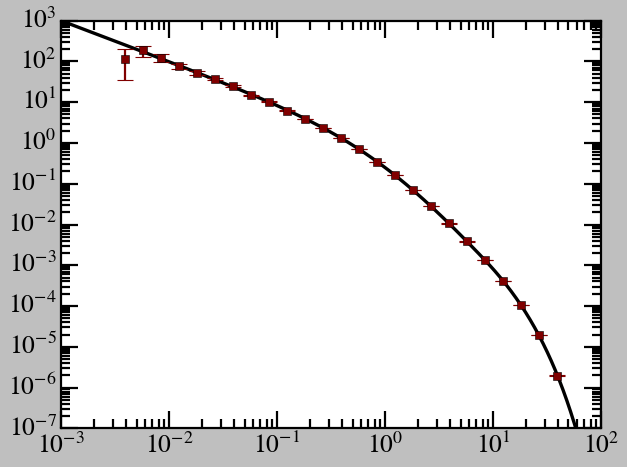

In [54]:
bin_centers, rho_bins, rho_bins_err = halo_inspection.get_sampled_rho()

plt.plot(
    nfw_ics.r_bins / nfw_ics.rs,
    nfw_ics.rho_bins / nfw_ics.rhos,
    label="NFW",
    color="black",
)
plt.errorbar(
    bin_centers,
    rho_bins,
    yerr=rho_bins_err,
    fmt=" s",
    markersize=7.5,
    elinewidth=2,
    capsize=7.5,
    capthick=1,
    label="Sampled",
    color="maroon",
)

plt.xscale("log")
plt.yscale("log")

plt.xlim(1e-3, 1e2)
plt.ylim(1e-7, 1e3)

plt.tight_layout()
plt.show()

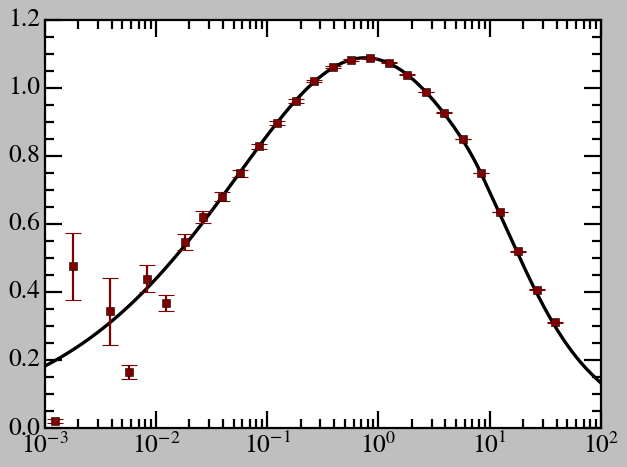

In [55]:
bin_centers, sigmas, sigmas_err = halo_inspection.get_sampled_sigma()

plt.plot(
    nfw_ics.r_bins / nfw_ics.rs,
    nfw_ics.sigma_r_bins / np.sqrt(G * nfw_ics.rhos * nfw_ics.rs**2),
    label="NFW",
    color="black",
)
plt.errorbar(
    bin_centers,
    sigmas,
    yerr=sigmas_err,
    fmt=" s",
    markersize=7.5,
    elinewidth=2,
    capsize=7.5,
    capthick=1,
    label="Sampled",
    color="maroon",
)

plt.xscale("log")

plt.xlim(1e-3, 1e2)
plt.ylim(0, 1.2)

plt.tight_layout()
plt.show()